## Hard-negative / boundary undersampling (classical geometry baselines)

NearMiss (variants), Tomek links, Edited Nearest Neighbors (ENN) or Neighborhood Cleaning Rule (NCL).
These are standard “keep boundary points / clean majority” methods.

In [1]:

import importlib
import pandas as pd
import numpy as np
import os, pickle
import public.model_IAI
importlib.reload(public.model_IAI)
from public.model_IAI import evaluate_binary_oct, finetune_oct

df_og  = pd.read_parquet("0917_2017_18_with_2017_cost.parquet")

TRAIN_TEST_SEED = 123 #9012

# Fetch helper functions directly from public.model_IAI
get_bin_flag_columns = public.model_IAI.get_bin_flag_columns
get_true_num_columns = public.model_IAI.get_true_num_columns
train_test_split_enrol = public.model_IAI.train_test_split_enrol

BIN_FLAG_COLUMNS = get_bin_flag_columns(df_og) 
STAGE_COLUMNS = [col for col in df_og.columns if "stage" in col.lower()]
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = get_true_num_columns(df_og, CAT_COLUMNS, BIN_FLAG_COLUMNS) 

print("categorical cols: ", CAT_COLUMNS)
print("stage cols: ", STAGE_COLUMNS)
print("bin flag cols: ", BIN_FLAG_COLUMNS)
print("true num cols: ", TRUE_NUM_COLUMNS)
leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

def make_cost_stratum_3class(df):
    # Default to low-cost (class 0)
    cost_stratum = pd.Series(0, index=df.index)
    cost_stratum[(df['highcost_gt_50000'] == 1) & (df['highcost_gt_100000'] == 0)] = 1
    # Emergent high cost (class 2): 100k to 200k
    cost_stratum[(df['highcost_gt_100000'] == 1) & (df['highcost_gt_200000'] == 0)] = 2
    # High cost (class 2): 200k+
    cost_stratum[df['highcost_gt_200000'] == 1] = 3
    return cost_stratum

# Add the new column to your data
df_og['cost_stratum_2018'] = make_cost_stratum_3class(df_og)
print(df_og["cost_stratum_2018"].value_counts(dropna=False))

cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
    if c not in  (['annual_cost_2017','annual_cost_2018_deflated',"ENROLID", "cost_stratum_2018"] + cutoff_columns)
]
numeric_cols = df_og[feature_cols + ["cost_stratum_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["cost_stratum_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "cost_stratum_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ", high_corr_cols)
target_col = "highcost_gt_200000"

# Split data into train/test/val (same as multiobjective_bilevel.ipynb)
train_ids, test_ids, train_pd, test_pd = train_test_split_enrol(
    df_og,
    target_col="cost_stratum_2018",
    test_size=0.3,
    verbose=False,
    random_state=TRAIN_TEST_SEED
)
print(f"Train shape: {train_pd.shape}, Test shape: {test_pd.shape}")
print("Feature cols:", len(feature_cols))

val_ids, test_ids, val_pd, test_pd = train_test_split_enrol(
    test_pd, 
    target_col=target_col,
    test_size=0.5,
    verbose=False,
    random_state=TRAIN_TEST_SEED
)
X_test = test_pd[feature_cols]
y_test = test_pd[target_col]
X_val = val_pd[feature_cols]
y_val = val_pd[target_col]

print(f"Train: {train_pd.shape}, Val: {val_pd.shape}, Test: {test_pd.shape}")
print(f"Train target distribution:\n{train_pd[target_col].value_counts()}")

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
stage cols:  ['stage_2017', '2017Q1_max_ckd_stage', '2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage', '2017Q4_max_ckd_stage']
bin flag cols:  ['highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'Antihyperlipidemic Drugs, NEC (THRCLS_53)', 'Cardiac, Beta Blockers (THRCLS_51)', 'Cardiac, Calcium Channel (THRCLS

In [2]:
# ============================================================================
# COMPETING UNDERSAMPLING METHODS: NearMiss, Tomek Links, ENN, NCL
# ============================================================================

from imblearn.under_sampling import NearMiss, TomekLinks, EditedNearestNeighbours, NeighbourhoodCleaningRule
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# OCT hyperparameters (same as other scripts)
OCT_DEPTHS = [7, 9]
OCT_MINBUCKETS = [50, 100, 120, 150]
OCT_CPS = [0.00001, 0.0001, 0.001, 0.01]

# Prepare training data
X_train_raw = train_pd[feature_cols].copy()
y_train = train_pd[target_col].copy()

print("="*80)
print("ORIGINAL TRAINING DATA")
print("="*80)
print(f"Shape: {X_train_raw.shape}")
print(f"Target distribution:")
print(y_train.value_counts())
print(f"Class ratio: {(y_train == 0).sum()}:{(y_train == 1).sum()} (majority:minority)")

# Preprocess features for distance-based methods
# These methods need numeric features, so we'll use the preprocessor
from public.model_IAI import get_preprocessor_with_impute
preprocessor_train = get_preprocessor_with_impute(
    X_train_raw,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    binary_cols=BIN_FLAG_COLUMNS,
    verbose=False
)
X_train_processed = preprocessor_train.fit_transform(X_train_raw)
print(f"\nProcessed training data shape: {X_train_processed.shape}")


ORIGINAL TRAINING DATA
Shape: (23479, 78)
Target distribution:
highcost_gt_200000
0    22819
1      660
Name: count, dtype: int64
Class ratio: 22819:660 (majority:minority)

Processed training data shape: (23479, 90)


## APPLY UNDERSAMPLING METHODS

In [13]:
# ============================================================================
# APPLY UNDERSAMPLING METHODS
# ============================================================================
# Note: ENN and NCL are cleaning methods (remove noisy samples), not aggressive undersamplers.
# They typically remove only a small percentage of majority samples.

def reconstruct_dataframe_from_resampled(X_res, y_res, X_original_processed, train_df_original):
    """Reconstruct dataframe from resampled data by matching to original indices."""
    # Convert resampled arrays to DataFrames for comparison
    X_res_df = pd.DataFrame(X_res)
    X_orig_df = pd.DataFrame(X_original_processed)
    
    # Create a mapping by matching rows
    # This is approximate but works for most cases
    matching_indices = []
    for idx in range(len(X_res_df)):
        row = X_res_df.iloc[idx]
        # Find matching rows in original (use first match)
        matches = (X_orig_df == row).all(axis=1)
        if matches.any():
            matching_indices.append(X_orig_df.index[matches][0])
        else:
            # If no exact match, find closest (using hamming distance on boolean)
            # Fallback: use first available index (shouldn't happen often)
            pass
    
    # Alternative: if sample_indices_ is available, use it
    # Otherwise, match by row values
    if len(matching_indices) == len(X_res):
        return train_df_original.iloc[matching_indices].reset_index(drop=True)
    else:
        # Fallback: create new dataframe from resampled data
        # This won't have all original columns, so we'll use a different approach
        raise ValueError("Could not reconstruct dataframe from resampled indices")

undersampled_datasets = {}
undersampling_methods = {}

print("="*80)
print("APPLYING UNDERSAMPLING METHODS")
print("="*80)
print("\nNOTE: ENN and NCL are cleaning methods (remove noisy samples), not aggressive undersamplers.")
print("      They typically remove only 1-5% of majority samples.")

# Helper function to get indices from resampled data
def get_indices_from_resampler(resampler, X_original, y_original, X_resampled, y_resampled):
    """Get original indices from resampler."""
    # Try to use sample_indices_ if available
    if hasattr(resampler, 'sample_indices_') and resampler.sample_indices_ is not None:
        return resampler.sample_indices_
    
    # Otherwise, match rows to find indices
    # Create indices list by matching resampled rows to original
    indices = []
    X_orig_df = pd.DataFrame(X_original)
    X_res_df = pd.DataFrame(X_resampled)
    
    for idx_res in range(len(X_res_df)):
        row_res = X_res_df.iloc[idx_res].values
        # Find matching row in original (tolerance for floating point)
        matches = np.allclose(X_orig_df.values, row_res, atol=1e-6, axis=1)
        if matches.any():
            # Take first match
            orig_idx = X_orig_df.index[matches][0]
            if orig_idx not in indices:
                indices.append(orig_idx)
        else:
            # Find closest match using Euclidean distance
            distances = np.linalg.norm(X_orig_df.values - row_res, axis=1)
            closest_idx = X_orig_df.index[np.argmin(distances)]
            if closest_idx not in indices:
                indices.append(closest_idx)
    
    return indices

# 1. NearMiss-1: Select majority samples closest to minority samples
print("\n1. NearMiss-1: Selecting majority samples closest to minority...")
try:
    nm1 = NearMiss(version=1, n_neighbors=3)  # Removed random_state
    X_res_nm1, y_res_nm1 = nm1.fit_resample(X_train_processed, y_train.values)
    
    # Get original indices
    indices_nm1 = get_indices_from_resampler(nm1, X_train_processed, y_train.values, X_res_nm1, y_res_nm1)
    undersampled_nm1 = train_pd.iloc[indices_nm1].reset_index(drop=True)
    
    undersampled_datasets['NearMiss-1'] = undersampled_nm1
    undersampling_methods['NearMiss-1'] = nm1
    
    print(f"  ✓ NearMiss-1: {len(undersampled_nm1):,} samples")
    print(f"    Distribution: {undersampled_nm1[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_nm1):,} ({len(undersampled_nm1)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with NearMiss-1: {e}")
    import traceback
    traceback.print_exc()

# 2. NearMiss-2: Select majority samples closest to farthest minority samples
print("\n2. NearMiss-2: Selecting majority samples closest to farthest minority...")
try:
    nm2 = NearMiss(version=2, n_neighbors=3)  # Removed random_state
    X_res_nm2, y_res_nm2 = nm2.fit_resample(X_train_processed, y_train.values)
    
    indices_nm2 = get_indices_from_resampler(nm2, X_train_processed, y_train.values, X_res_nm2, y_res_nm2)
    undersampled_nm2 = train_pd.iloc[indices_nm2].reset_index(drop=True)
    
    undersampled_datasets['NearMiss-2'] = undersampled_nm2
    undersampling_methods['NearMiss-2'] = nm2
    
    print(f"  ✓ NearMiss-2: {len(undersampled_nm2):,} samples")
    print(f"    Distribution: {undersampled_nm2[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_nm2):,} ({len(undersampled_nm2)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with NearMiss-2: {e}")
    import traceback
    traceback.print_exc()

# 3. NearMiss-3: Select majority samples with minimum average distance to k nearest minority samples
print("\n3. NearMiss-3: Selecting majority with min avg distance to k nearest minority...")
try:
    nm3 = NearMiss(version=3, n_neighbors=3)  # Removed random_state
    X_res_nm3, y_res_nm3 = nm3.fit_resample(X_train_processed, y_train.values)
    
    indices_nm3 = get_indices_from_resampler(nm3, X_train_processed, y_train.values, X_res_nm3, y_res_nm3)
    undersampled_nm3 = train_pd.iloc[indices_nm3].reset_index(drop=True)
    
    undersampled_datasets['NearMiss-3'] = undersampled_nm3
    undersampling_methods['NearMiss-3'] = nm3
    
    print(f"  ✓ NearMiss-3: {len(undersampled_nm3):,} samples")
    print(f"    Distribution: {undersampled_nm3[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_nm3):,} ({len(undersampled_nm3)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with NearMiss-3: {e}")
    import traceback
    traceback.print_exc()

# 4. Tomek Links: Remove Tomek link pairs (noise cleaning - minimal undersampling)
print("\n4. Tomek Links: Removing Tomek link pairs (noise cleaning)...")
print("   NOTE: Tomek Links is a cleaning method - it removes only noisy samples, not aggressive undersampling")
try:
    tomek = TomekLinks(sampling_strategy='majority')  # Removed random_state
    X_res_tomek, y_res_tomek = tomek.fit_resample(X_train_processed, y_train.values)
    
    indices_tomek = get_indices_from_resampler(tomek, X_train_processed, y_train.values, X_res_tomek, y_res_tomek)
    undersampled_tomek = train_pd.iloc[indices_tomek].reset_index(drop=True)
    
    undersampled_datasets['TomekLinks'] = undersampled_tomek
    undersampling_methods['TomekLinks'] = tomek
    
    print(f"  ✓ Tomek Links: {len(undersampled_tomek):,} samples")
    print(f"    Distribution: {undersampled_tomek[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_tomek):,} ({len(undersampled_tomek)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with Tomek Links: {e}")
    import traceback
    traceback.print_exc()

# 5. Edited Nearest Neighbors (ENN): Remove majority samples misclassified by k-NN (cleaning)
print("\n5. Edited Nearest Neighbors (ENN): Removing misclassified majority samples...")
print("   NOTE: ENN is a cleaning method - removes noisy samples, typically 1-5% reduction")
try:
    enn = EditedNearestNeighbours(sampling_strategy='majority', n_neighbors=3, kind_sel='all')
    X_res_enn, y_res_enn = enn.fit_resample(X_train_processed, y_train.values)
    
    indices_enn = get_indices_from_resampler(enn, X_train_processed, y_train.values, X_res_enn, y_res_enn)
    undersampled_enn = train_pd.iloc[indices_enn].reset_index(drop=True)
    
    undersampled_datasets['ENN'] = undersampled_enn
    undersampling_methods['ENN'] = enn
    
    print(f"  ✓ ENN: {len(undersampled_enn):,} samples")
    print(f"    Distribution: {undersampled_enn[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_enn):,} ({len(undersampled_enn)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with ENN: {e}")
    import traceback
    traceback.print_exc()

# 6. Neighborhood Cleaning Rule (NCL): More aggressive cleaning than ENN (but still cleaning)
print("\n6. Neighborhood Cleaning Rule (NCL): More aggressive cleaning than ENN...")
print("   NOTE: NCL is a cleaning method - removes more noisy samples than ENN, but still limited reduction")
try:
    ncl = NeighbourhoodCleaningRule(sampling_strategy='majority', n_neighbors=3, kind_sel='all')
    X_res_ncl, y_res_ncl = ncl.fit_resample(X_train_processed, y_train.values)
    
    indices_ncl = get_indices_from_resampler(ncl, X_train_processed, y_train.values, X_res_ncl, y_res_ncl)
    undersampled_ncl = train_pd.iloc[indices_ncl].reset_index(drop=True)
    
    undersampled_datasets['NCL'] = undersampled_ncl
    undersampling_methods['NCL'] = ncl
    
    print(f"  ✓ NCL: {len(undersampled_ncl):,} samples")
    print(f"    Distribution: {undersampled_ncl[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_ncl):,} ({len(undersampled_ncl)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with NCL: {e}")
    import traceback
    traceback.print_exc()

# 7. Random UnderSampler (for comparison - aggressive 1:1 ratio)
print("\n7. Random UnderSampler: Random undersampling to 1:1 ratio (for comparison)...")
from imblearn.under_sampling import RandomUnderSampler
try:
    rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
    X_res_rus, y_res_rus = rus.fit_resample(X_train_processed, y_train.values)
    
    indices_rus = get_indices_from_resampler(rus, X_train_processed, y_train.values, X_res_rus, y_res_rus)
    undersampled_rus = train_pd.iloc[indices_rus].reset_index(drop=True)
    
    undersampled_datasets['RandomUnderSampler'] = undersampled_rus
    undersampling_methods['RandomUnderSampler'] = rus
    
    print(f"  ✓ Random UnderSampler: {len(undersampled_rus):,} samples")
    print(f"    Distribution: {undersampled_rus[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_rus):,} ({len(undersampled_rus)/len(train_pd)*100:.1f}%)")
except Exception as e:
    print(f"  ✗ Error with Random UnderSampler: {e}")
    import traceback
    traceback.print_exc()

print(f"\n{'='*80}")
print(f"Successfully created {len(undersampled_datasets)} undersampled datasets")
print("="*80)
print("\nSummary:")
print(f"{'Method':<20s} {'Samples':>10s} {'Reduction':>12s} {'Minority':>10s} {'Majority':>10s}")
print("-" * 70)
for method, df in undersampled_datasets.items():
    reduction_pct = (1 - len(df)/len(train_pd)) * 100
    n_minority = (df[target_col] == 1).sum()
    n_majority = (df[target_col] == 0).sum()
    print(f"{method:<20s} {len(df):>10,} {reduction_pct:>11.1f}% {n_minority:>10,} {n_majority:>10,}")

# Create directory for saving predictions
predictions_dir = f"competing_methods_results/predictions_seed_{TRAIN_TEST_SEED}"
os.makedirs(predictions_dir, exist_ok=True)

APPLYING UNDERSAMPLING METHODS

NOTE: ENN and NCL are cleaning methods (remove noisy samples), not aggressive undersamplers.
      They typically remove only 1-5% of majority samples.

1. NearMiss-1: Selecting majority samples closest to minority...
  ✓ NearMiss-1: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)

2. NearMiss-2: Selecting majority samples closest to farthest minority...
  ✓ NearMiss-2: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)

3. NearMiss-3: Selecting majority with min avg distance to k nearest minority...
  ✓ NearMiss-3: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)

4. Tomek Links: Removing Tomek link pairs (noise cleaning)...
   NOTE: Tomek Links is a cleaning method - it removes only noisy samples, not aggressive undersampling
  ✓ Tomek Links: 23,342 samples
    Distribution: {0: 22682, 1: 660}
    Reduction: 23,479 → 23,342 (99.4%)

5. Edited N

## Train a bunch of random seed undersampler

In [11]:
# 7. Random UnderSampler (for comparison - aggressive 1:1 ratio)
print("\n7. Random UnderSampler: Random undersampling to 1:1 ratio (for comparison)...")
from imblearn.under_sampling import RandomUnderSampler
random_undersampled_datasets = {}
random_undersampling_methods = {}
for seed in range(10):
    rus = RandomUnderSampler(sampling_strategy='auto', random_state=seed)
    X_res_rus, y_res_rus = rus.fit_resample(X_train_processed, y_train.values)

    indices_rus = get_indices_from_resampler(rus, X_train_processed, y_train.values, X_res_rus, y_res_rus)
    undersampled_rus = train_pd.iloc[indices_rus].reset_index(drop=True)
    
    random_undersampled_datasets['RandomUnderSampler_seed_'+str(seed)] = undersampled_rus
    random_undersampling_methods['RandomUnderSampler_seed_'+str(seed)] = rus
    
    print(f"  ✓ Random UnderSampler: {len(undersampled_rus):,} samples")
    print(f"    Distribution: {undersampled_rus[target_col].value_counts().to_dict()}")
    print(f"    Reduction: {len(train_pd):,} → {len(undersampled_rus):,} ({len(undersampled_rus)/len(train_pd)*100:.1f}%)")
    
# ============================================================================
# TRAIN AND EVALUATE OCT MODELS ON EACH UNDERSAMPLED DATASET
# ============================================================================

print("="*80)
print("TRAINING OCT MODELS ON UNDERSAMPLED DATASETS")
print("="*80)

random_avg_results = []

for method_name, undersampled_df in random_undersampled_datasets.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name}")
    print(f"{'='*80}")
    
    n_samples = len(undersampled_df)
    n_minority = (undersampled_df[target_col] == 1).sum()
    n_majority = (undersampled_df[target_col] == 0).sum()
    
    print(f"Dataset size: {n_samples:,} samples")
    print(f"  Minority: {n_minority:,}")
    print(f"  Majority: {n_majority:,}")
    print(f"  Ratio: {n_majority/n_minority:.2f}:1")
    

    # Train OCT model
    print(f"\n  Training OCT model...")
    balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
        X_train=undersampled_df[feature_cols],
        y_train=undersampled_df[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=OCT_DEPTHS,
        minbuckets=OCT_MINBUCKETS,
        cps=OCT_CPS,
    )
    
    print(f"    ✓ Training complete")
    print(f"    Best params: {balanced_params}")
    
    # Evaluate on test set and save predictions
    print(f"  Evaluating on test set...")
    # Save predictions to method-specific directory
    method_results_dir = f"competing_methods_results/{method_name}"
    metrics = evaluate_binary_oct(
        balanced_model, X_test, y_test, preprocessor, feature_names,
        results_dir=method_results_dir, ratio=None
    )
    
    # Store results
    result_row = {
        'method': method_name,
        'n_train_samples': n_samples,
        'n_train_minority': n_minority,
        'n_train_majority': n_majority,
        'best_depth': balanced_params[0] if isinstance(balanced_params, tuple) else None,
        'best_minbucket': balanced_params[1] if isinstance(balanced_params, tuple) else None,
        'best_cp': balanced_params[2] if isinstance(balanced_params, tuple) else None,
    }
    
    if isinstance(metrics, dict):
        result_row.update(metrics)
        print(f"    ✓ Evaluation complete")
        print(f"      AUC: {metrics.get('auc', 'N/A'):.4f}" if isinstance(metrics.get('auc'), (int, float)) else f"      AUC: {metrics.get('auc', 'N/A')}")
        print(f"      PR-AUC: {metrics.get('pr_auc', 'N/A'):.4f}" if isinstance(metrics.get('pr_auc'), (int, float)) else f"      PR-AUC: {metrics.get('pr_auc', 'N/A')}")
        print(f"      MCC: {metrics.get('best_mcc', 'N/A'):.4f}" if isinstance(metrics.get('best_mcc'), (int, float)) else f"      MCC: {metrics.get('best_mcc', 'N/A')}")
        print(f"      Recall (G-mean): {metrics.get('balanced_recall_gmean', 'N/A'):.4f}" if isinstance(metrics.get('balanced_recall_gmean'), (int, float)) else f"      Recall (G-mean): {metrics.get('balanced_recall_gmean', 'N/A')}")
    else:
        result_row['error'] = str(metrics)
        print(f"    ✗ Evaluation error: {metrics}")
    
    random_avg_results.append(result_row)
            
random_avg_results


7. Random UnderSampler: Random undersampling to 1:1 ratio (for comparison)...
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 samples
    Distribution: {0: 660, 1: 660}
    Reduction: 23,479 → 1,320 (5.6%)
  ✓ Random UnderSampler: 1,320 sa

[{'method': 'RandomUnderSampler_seed_0',
  'n_train_samples': 1320,
  'n_train_minority': np.int64(660),
  'n_train_majority': np.int64(660),
  'best_depth': 7,
  'best_minbucket': 150,
  'best_cp': 1e-05,
  'auc': 0.8134040438952734,
  'pr_auc': np.float64(0.09043367194564267),
  'best_mcc': 0.2345594885184981,
  'best_mcc_threshold': 0.5398789346246974,
  'recall_mcc': 0.7394366197183099,
  'precision_mcc': 0.10725229826353422,
  'optimal_f1': 0.18733273860410127,
  'balanced_recall_gmean': 0.7394366197183099,
  'balanced_specificity_gmean': 0.8212678936605317,
  'precision_gmean': 0.10725229826353422},
 {'method': 'RandomUnderSampler_seed_1',
  'n_train_samples': 1320,
  'n_train_minority': np.int64(660),
  'n_train_majority': np.int64(660),
  'best_depth': 7,
  'best_minbucket': 50,
  'best_cp': 0.01,
  'auc': 0.8019060168783663,
  'pr_auc': np.float64(0.08353223742808139),
  'best_mcc': 0.22232698069332915,
  'best_mcc_threshold': 0.5540404040404041,
  'recall_mcc': 0.746478873239

## TRAIN AND EVALUATE OCT MODELS ON EACH UNDERSAMPLED DATASET

In [11]:
# ============================================================================
# TRAIN AND EVALUATE OCT MODELS ON EACH UNDERSAMPLED DATASET
# ============================================================================

print("="*80)
print("TRAINING OCT MODELS ON UNDERSAMPLED DATASETS")
print("="*80)

all_results = []

for method_name, undersampled_df in undersampled_datasets.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name}")
    print(f"{'='*80}")
    
    n_samples = len(undersampled_df)
    n_minority = (undersampled_df[target_col] == 1).sum()
    n_majority = (undersampled_df[target_col] == 0).sum()
    
    print(f"Dataset size: {n_samples:,} samples")
    print(f"  Minority: {n_minority:,}")
    print(f"  Majority: {n_majority:,}")
    print(f"  Ratio: {n_majority/n_minority:.2f}:1")
    
    try:
        # Train OCT model
        print(f"\n  Training OCT model...")
        balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
            X_train=undersampled_df[feature_cols],
            y_train=undersampled_df[target_col],
            X_val=X_val,
            y_val=y_val,
            categorical_cols=CAT_COLUMNS,
            numeric_cols=TRUE_NUM_COLUMNS,
            depths=OCT_DEPTHS,
            minbuckets=OCT_MINBUCKETS,
            cps=OCT_CPS,
        )
        
        print(f"    ✓ Training complete")
        print(f"    Best params: {balanced_params}")
        
        # Evaluate on test set and save predictions
        print(f"  Evaluating on test set...")
        # Save predictions to method-specific directory
        method_results_dir = f"competing_methods_results/{method_name}_seed_{TRAIN_TEST_SEED}"
        metrics = evaluate_binary_oct(
            balanced_model, X_test, y_test, preprocessor, feature_names,
            results_dir=method_results_dir, ratio=None
        )
        
        # Store results
        result_row = {
            'method': method_name,
            'n_train_samples': n_samples,
            'n_train_minority': n_minority,
            'n_train_majority': n_majority,
            'best_depth': balanced_params[0] if isinstance(balanced_params, tuple) else None,
            'best_minbucket': balanced_params[1] if isinstance(balanced_params, tuple) else None,
            'best_cp': balanced_params[2] if isinstance(balanced_params, tuple) else None,
        }
        
        if isinstance(metrics, dict):
            result_row.update(metrics)
            print(f"    ✓ Evaluation complete")
            print(f"      AUC: {metrics.get('auc', 'N/A'):.4f}" if isinstance(metrics.get('auc'), (int, float)) else f"      AUC: {metrics.get('auc', 'N/A')}")
            print(f"      PR-AUC: {metrics.get('pr_auc', 'N/A'):.4f}" if isinstance(metrics.get('pr_auc'), (int, float)) else f"      PR-AUC: {metrics.get('pr_auc', 'N/A')}")
            print(f"      MCC: {metrics.get('best_mcc', 'N/A'):.4f}" if isinstance(metrics.get('best_mcc'), (int, float)) else f"      MCC: {metrics.get('best_mcc', 'N/A')}")
            print(f"      Recall (G-mean): {metrics.get('balanced_recall_gmean', 'N/A'):.4f}" if isinstance(metrics.get('balanced_recall_gmean'), (int, float)) else f"      Recall (G-mean): {metrics.get('balanced_recall_gmean', 'N/A')}")
        else:
            result_row['error'] = str(metrics)
            print(f"    ✗ Evaluation error: {metrics}")
        
        all_results.append(result_row)
        
    except Exception as e:
        print(f"    ✗ ERROR: {e}")
        import traceback
        traceback.print_exc()
        
        all_results.append({
            'method': method_name,
            'n_train_samples': n_samples,
            'error': str(e)
        })

print(f"\n{'='*80}")
print("ALL MODELS TRAINED AND EVALUATED")
print("="*80)


TRAINING OCT MODELS ON UNDERSAMPLED DATASETS

METHOD: NearMiss-1
Dataset size: 1,320 samples
  Minority: 660
  Majority: 660
  Ratio: 1.00:1

  Training OCT model...
Finetuning OCT with depths: [7, 9], minbuckets: [50, 100, 120, 150], cps: [1e-05, 0.0001, 0.001, 0.01], for best PR-AUC!!!
→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_20

In [14]:
# ============================================================================
# COMPARISON: RESULTS SUMMARY AND RANKINGS
# ============================================================================

results_df = pd.DataFrame(all_results)

print("="*80)
print("COMPARISON OF COMPETING METHODS")
print("="*80)

# Display results table
if len(results_df) > 0:
    display_cols = ['method', 'n_train_samples', 'n_train_minority', 'n_train_majority']
    metric_cols = ['auc', 'pr_auc', 'best_mcc', 'balanced_recall_gmean', 'balanced_specificity_gmean', 'optimal_f1']
    
    for col in metric_cols:
        if col in results_df.columns:
            display_cols.append(col)
    
    display_cols = [c for c in display_cols if c in results_df.columns]
    
    # Format numeric columns
    for col in metric_cols:
        if col in results_df.columns:
            results_df[col] = results_df[col].apply(
                lambda x: f"{x:.4f}" if pd.notna(x) and isinstance(x, (int, float)) else "N/A"
            )
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 30)
    
    print("\n" + "="*80)
    print("ALL METHODS - COMPLETE RESULTS")
    print("="*80)
    print(results_df[display_cols].to_string(index=False))
    
    # Rankings by different metrics
    if 'auc' in results_df.columns:
        print("\n" + "="*80)
        print("RANKING BY AUC (descending)")
        print("="*80)
        # Convert back to numeric for sorting
        results_df['auc_numeric'] = pd.to_numeric(results_df['auc'], errors='coerce')
        sorted_by_auc = results_df.sort_values('auc_numeric', ascending=False)
        print(sorted_by_auc[display_cols].to_string(index=False))
        
        if 'best_mcc' in results_df.columns:
            print("\n" + "="*80)
            print("RANKING BY MCC (descending)")
            print("="*80)
            results_df['mcc_numeric'] = pd.to_numeric(results_df['best_mcc'], errors='coerce')
            sorted_by_mcc = results_df.sort_values('mcc_numeric', ascending=False)
            print(sorted_by_mcc[display_cols].to_string(index=False))
        
        if 'pr_auc' in results_df.columns:
            print("\n" + "="*80)
            print("RANKING BY PR-AUC (descending)")
            print("="*80)
            results_df['pr_auc_numeric'] = pd.to_numeric(results_df['pr_auc'], errors='coerce')
            sorted_by_pr_auc = results_df.sort_values('pr_auc_numeric', ascending=False)
            print(sorted_by_pr_auc[display_cols].to_string(index=False))
    
    # Save results
    output_dir = "competing_methods_results"
    #os.makedirs(output_dir, exist_ok=True)
    #results_path = f"{output_dir}/competing_methods_metrics.csv"
    #results_df.to_csv(results_path, index=False)
    #print(f"\n{'='*80}")
    #print(f"✓ Results saved to: {results_path}")
    #print("="*80)
else:
    print("⚠️ No results to display")


COMPARISON OF COMPETING METHODS

ALL METHODS - COMPLETE RESULTS
            method  n_train_samples  n_train_minority  n_train_majority    auc pr_auc best_mcc balanced_recall_gmean balanced_specificity_gmean optimal_f1
        NearMiss-1             1320               660               660 0.7977 0.0950   0.2125                0.7254                     0.7998     0.1995
        NearMiss-2             1320               660               660 0.3125 0.0205   0.0000                0.8028                     0.0413     0.0549
        NearMiss-3             1320               660               660 0.2430 0.0181   0.0000                0.5070                     0.1532     0.0549
        TomekLinks            23358               660             22698 0.6209 0.1452   0.2916                0.2535                     0.9871     0.2988
               ENN            22406               660             21746 0.6618 0.1899   0.3777                0.3451                     0.9732     0.3810
      

## SYMMETRIC LEAF EVALUATION: resampling baselines
============================================================================


In [6]:
print(f"\n{'='*80}")
print("SYMMETRIC EVALUATION COMPLETE")
print("="*80)

# Summary table of symmetric excess metrics
if len(symmetric_results) > 0:
    print("\n" + "="*80)
    print("SUMMARY: SYMMETRIC EXCESS AUC (vanilla vs IAI autobalance)")
    print("="*80)
    
    summary_data = []
    for method_name, results in symmetric_results.items():
        if 'scores' in results:
            scores = results['scores']
            summary_data.append({
                'method': method_name,
                'excess_ROC_s|v': scores.get('excess_ROC_s|v', np.nan),
                'excess_ROC_v|s': scores.get('excess_ROC_v|s', np.nan),
                'sym_excess_ROC': scores.get('sym_excess_ROC', np.nan),
                'coverage_v': scores.get('coverage_informative_v', np.nan),
                'coverage_s': scores.get('coverage_informative_s', np.nan),
            })
    
    if summary_data:
        symmetric_summary_df = pd.DataFrame(summary_data)
        print("\n" + symmetric_summary_df.to_string(index=False))
        
        # Rank by symmetric excess ROC
        print("\n" + "="*80)
        print("RANKING BY SYMMETRIC EXCESS ROC (descending)")
        print("="*80)
        sorted_symmetric = symmetric_summary_df.sort_values('sym_excess_ROC', ascending=False, )
        print(sorted_symmetric.to_string(index=False))
        
        # Save symmetric evaluation results
        symmetric_path = "competing_methods_results/symmetric_evaluation_results.csv"
        symmetric_summary_df.to_csv(symmetric_path, index=False)
        print(f"\n✓ Symmetric evaluation results saved to: {symmetric_path}")


SYMMETRIC EVALUATION COMPLETE

SUMMARY: SYMMETRIC EXCESS AUC BY METHOD

                   method  excess_ROC_s|v  excess_ROC_v|s  sym_excess_ROC  coverage_v  coverage_s
                      ENN        0.065718        0.002644        0.034181    0.992448    0.995429
                      NCL        0.162518        0.002016        0.082267    0.992448    0.987281
               NearMiss-1        0.267578        0.017600        0.142589    0.992448    0.985294
               NearMiss-2       -0.089037        0.042301       -0.023368    0.992448    0.969595
               NearMiss-3       -0.254397        0.014376       -0.120010    0.992448    0.956479
       RandomUnderSampler        0.322761        0.012110        0.167436    0.992448    1.000000
               TomekLinks        0.059487        0.000705        0.030096    0.992448    0.989269
RandomUnderSampler_seed_0        0.299767        0.034661        0.167214    0.992448    0.580485
RandomUnderSampler_seed_1        0.288408    

## Vanilla model

In [19]:
# ============================================================================
# TRAIN VANILLA OCT BASELINE (on full imbalanced training data)
# ============================================================================

print("="*80)
print("TRAINING VANILLA OCT BASELINE")
print("="*80)
print("Training on full imbalanced training data for comparison...")

try:
    # Train vanilla OCT on full imbalanced training data
    vanilla_model, vanilla_params, _, vanilla_preprocessor, vanilla_feature_names = finetune_oct(
        X_train=train_pd[feature_cols],
        y_train=train_pd[target_col],
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        depths=[7,9],
        minbuckets=[150],
        cps=[1e-5],
    )
    
    print(f"✓ Vanilla OCT training complete")
    print(f"  Best params: {vanilla_params}")
    vanilla_train_time_seconds = (
        vanilla_params.get("tuning_time_seconds", np.nan)
        if isinstance(vanilla_params, dict)
        else np.nan
    )
    if pd.notna(vanilla_train_time_seconds):
        print(f"  Training time (tuning): {vanilla_train_time_seconds:.2f}s")
    
    # Evaluate and save predictions for vanilla model
    vanilla_results_dir = f"vanilla_oct/seed_{TRAIN_TEST_SEED}"
    vanilla_metrics = evaluate_binary_oct(
        vanilla_model, X_test, y_test, vanilla_preprocessor, vanilla_feature_names,
        results_dir=vanilla_results_dir,X_val_df=X_val,y_val=y_val
    )
    if isinstance(vanilla_metrics, dict):
        vanilla_metrics["training_time_seconds"] = vanilla_train_time_seconds
    
    print(f"\n✓ Vanilla OCT predictions saved")
    print(f"  Predictions path: {vanilla_results_dir}/predictions/oct_predictions.csv")
    print(f"  AUC: {vanilla_metrics.get('auc', 'N/A'):.4f}" if isinstance(vanilla_metrics.get('auc'), (int, float)) else f"  AUC: {vanilla_metrics.get('auc', 'N/A')}")
    print(f"  PR-AUC: {vanilla_metrics.get('pr_auc', 'N/A'):.4f}" if isinstance(vanilla_metrics.get('pr_auc'), (int, float)) else f"  PR-AUC: {vanilla_metrics.get('pr_auc', 'N/A')}")
    print(f"  MCC: {vanilla_metrics.get('best_mcc', 'N/A'):.4f}" if isinstance(vanilla_metrics.get('best_mcc'), (int, float)) else f"  MCC: {vanilla_metrics.get('best_mcc', 'N/A')}")
    print(
        f"  Evaluation time: {vanilla_metrics.get('evaluation_time_seconds', np.nan):.2f}s"
        if isinstance(vanilla_metrics.get('evaluation_time_seconds'), (int, float))
        else f"  Evaluation time: {vanilla_metrics.get('evaluation_time_seconds', 'N/A')}"
    )
    
except Exception as e:
    print(f"✗ ERROR training vanilla OCT: {e}")
    import traceback
    traceback.print_exc()

TRAINING VANILLA OCT BASELINE
Training on full imbalanced training data for comparison...
Finetuning IAI OCT with variants=['oct'], depths=[7, 9], minbuckets=[150], cps=[1e-05] (best PR-AUC)
→ Building preprocessor w/ conditional imputation:
   • Cat: OHE on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • Num: scale on: ['stage_2017', 'util_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4

## New: IAI AUTOBALANCE OCT BASELINE (Reviewer DD7W ICML 03/25)

In [ ]:
# ============================================================================
# TRAIN IAI AUTOBALANCE OCT BASELINE (full imbalanced training data)
# ============================================================================

print("="*80)
print("TRAINING IAI AUTOBALANCE OCT BASELINE")
print("="*80)
print("Training on full imbalanced training data with IAI sample_weight=autobalance...")
OCT_DEPTHS = [5,7]
OCT_MINBUCKETS = [50, 100, 120, 150]
OCT_CPS = [0.01, 0.001, 0.0001, 0.00001]

auto_metrics = None

auto_model, auto_params, _, auto_preprocessor, auto_feature_names = finetune_oct(
    X_train=train_pd[feature_cols],
    y_train=train_pd[target_col],
    X_val=X_val,
    y_val=y_val,
    categorical_cols=CAT_COLUMNS,
    numeric_cols=TRUE_NUM_COLUMNS,
    depths=OCT_DEPTHS,
    minbuckets=OCT_MINBUCKETS,
    cps=OCT_CPS,
    fit_sample_weight="autobalance",
)

print("✓ IAI autobalance OCT training complete")
print(f"  Best params: {auto_params}")
auto_train_time_seconds = (
    auto_params.get("tuning_time_seconds", np.nan)
    if isinstance(auto_params, dict)
    else np.nan
)
if pd.notna(auto_train_time_seconds):
    print(f"  Training time (tuning): {auto_train_time_seconds:.2f}s")


TRAINING IAI AUTOBALANCE OCT BASELINE
Training on full imbalanced training data with IAI sample_weight=autobalance...
Finetuning IAI OCT with variants=['oct'], depths=[5, 7], minbuckets=[50, 100, 120, 150], cps=[0.01, 0.001, 0.0001, 1e-05] (best PR-AUC)
→ Building preprocessor w/ conditional imputation:
   • Cat: OHE on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • Num: scale on: ['stage_2017', 'util_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_max_ckd_stage', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_max_ckd_stage', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_max_ckd_stage',

In [4]:
#TODO rename the results directory
auto_results_dir = f"iai_autobalance_oct/seed_{TRAIN_TEST_SEED}_cp"


auto_metrics = evaluate_binary_oct(
    auto_model,
    X_test,
    y_test,
    auto_preprocessor,
    auto_feature_names,
    results_dir=auto_results_dir,
    X_val_df=X_val,
    y_val=y_val
    )
if isinstance(auto_metrics, dict):
    auto_metrics["training_time_seconds"] = auto_train_time_seconds

print("\n✓ IAI autobalance OCT predictions saved")
print(f"  Predictions path: {auto_results_dir}/predictions/oct_predictions.csv")
print(f"  AUC: {auto_metrics.get('auc', 'N/A'):.4f}" if isinstance(auto_metrics.get('auc'), (int, float)) else f"  AUC: {auto_metrics.get('auc', 'N/A')}")
print(f"  PR-AUC: {auto_metrics.get('pr_auc', 'N/A'):.4f}" if isinstance(auto_metrics.get('pr_auc'), (int, float)) else f"  PR-AUC: {auto_metrics.get('pr_auc', 'N/A')}")
print(f"  MCC: {auto_metrics.get('best_mcc', 'N/A'):.4f}" if isinstance(auto_metrics.get('best_mcc'), (int, float)) else f"  MCC: {auto_metrics.get('best_mcc', 'N/A')}")
print(f"  Recall (G-mean): {auto_metrics.get('balanced_recall_gmean', 'N/A'):.4f}" if isinstance(auto_metrics.get('balanced_recall_gmean'), (int, float)) else f"  Recall (G-mean): {auto_metrics.get('balanced_recall_gmean', 'N/A')}")
print(f"  Specificity (G-mean): {auto_metrics.get('balanced_specificity_gmean', 'N/A'):.4f}" if isinstance(auto_metrics.get('balanced_specificity_gmean'), (int, float)) else f"  Specificity (G-mean): {auto_metrics.get('balanced_specificity_gmean', 'N/A')}")
print(
    f"  Evaluation time: {auto_metrics.get('evaluation_time_seconds', np.nan):.2f}s"
    if isinstance(auto_metrics.get('evaluation_time_seconds'), (int, float))
    else f"  Evaluation time: {auto_metrics.get('evaluation_time_seconds', 'N/A')}"
)

Test dataset for OCT application: 5,032 samples
✓ Predictions completed
Computing optimal thresholds on validation set (5,031 samples)
  Applied validation-set thresholds to test set for evaluation
✓ Saved OCT predictions to: iai_autobalance_oct/seed_123_cp/predictions/oct_predictions.csv
✓ Saved split table (23 splits) to: iai_autobalance_oct/seed_123_cp/oct_tree_splits.csv
✓ Saved OCT tree visualization to: iai_autobalance_oct/seed_123_cp/oct_tree.html
AUC score: 0.823
PR-AUC (Average Precision): 0.154
Best MCC (test set, threshold from val): 0.230 @ threshold=0.911054
Sensitivity (Recall) @MCC*: 0.176
Specificity @MCC*: 0.990
Balanced (G-mean) recall (test set, threshold from val): 0.704
Balanced (G-mean) specificity (test set, threshold from val): 0.807
Recall @ specificity>=0.60: 0.761 (achieved spec=0.714, thr=0.260056)
Number of leaves: 24

✓ IAI autobalance OCT predictions saved
  Predictions path: iai_autobalance_oct/seed_123_cp/predictions/oct_predictions.csv
  AUC: 0.8234
  

In [12]:
auto_model.get_classification_proba(2)

{0: 0.8494120907856559, 1: 0.1505879092143448}

In [5]:
auto_model

Fitted OptimalTreeClassifier:
  1) Split: stage_2017 < 0.5575 or is missing
    2) Split: ckd_cost_trend_2017 < 0.04385 or is missing
      3) Split: quarterly_range_2017 < -0.04744 or is missing
        4) Split: 2017Q3_procedure_ckd_cost < 0.06345 or is missing
          5) Split: 2017Q4_ckd_claims < 0.9265 or is missing
            6) Predict: 0 (99.54%), [12456,58], 12514 points, error 0.1387
            7) Predict: 1 (5.63%), [67,4], 71 points, error 0.3264
          8) Split: util_2017 < 1.066 or is missing
            9) Predict: 0 (99.15%), [2786,24], 2810 points, error 0.2295
            10) Predict: 1 (6.35%), [177,12], 189 points, error 0.299
        11) Split: quarterly_min_2017 < -0.01104 or is missing
          12) Split: 2017Q4_procedure_ckd_cost < 0.4721 or is missing
            13) Predict: 0 (98.99%), [1176,12], 1188 points, error 0.2608
            14) Predict: 1 (5.83%), [226,14], 240 points, error 0.3183
          15) Split: 2017Q1_ckd_cost < -0.122 or is missing
            16) Predict: 0 (100.00%), [74,0], 74 points, error 0
            17) Predict: 1 (9.53%), [560,59], 619 points, error 0.2154
      18) Split: util_2017 < 0.8861 or is missing
        19) Split: 2017Q4_ckd_claims < 0.5714 or is missing
          20) Split: quarterly_range_2017 < 0.3888 or is missing
            21) Predict: 0 (98.99%), [787,8], 795 points, error 0.2601
            22) Predict: 1 (7.96%), [104,9], 113 points, error 0.2505
          23) Split: 2017Q4_ckd_claims < 1.43
            24) Predict: 0 (98.78%), [485,6], 491 points, error 0.2996
            25) Predict: 1 (6.67%), [196,14], 210 points, error 0.2882
        26) Predict: 1 (15.94%), [559,106], 665 points, error 0.1323
    27) Split: quarterly_range_2017 < -0.1602 or is missing
      28) Split: ckd_cost_deriv_Q3_Q4_2017 < -0.006882 or is missing
        29) Split: 2017Q1_procedure_ckd_cost < -0.1813 or is missing
          30) Split: 2017Q2_direct_ckd_cost < -0.08481 or is missing
            31) Predict: 0 (99.46%), [183,1], 184 points, error 0.1589
            32) Predict: 1 (5.81%), [162,10], 172 points, error 0.3191
          33) Split: 2017Q1_ckd_claims < 0.5088 or is missing
            34) Predict: 0 (99.47%), [377,2], 379 points, error 0.155
            35) Predict: 1 (5.45%), [52,3], 55 points, error 0.3339
        36) Split: quarterly_range_2017 < -0.2753 or is missing
          37) Split: REGION_2 < 0.5 or is missing
            38) Predict: 0 (99.32%), [437,3], 440 points, error 0.1918
            39) Predict: 1 (6.93%), [94,7], 101 points, error 0.2797
          40) Split: 2017Q4_procedure_ckd_cost < 0.78 or is missing
            41) Predict: 1 (8.20%), [504,45], 549 points, error 0.2447
            42) Predict: 0 (98.33%), [59,1], 60 points, error 0.3695
      43) Split: 2017Q4_ckd_cost < 1.184 or is missing
        44) Split: 2017Q3_ckd_cost < -0.1862 or is missing
          45) Predict: 0 (100.00%), [119,0], 119 points, error 0
          46) Predict: 1 (11.40%), [948,122], 1070 points, error 0.1835
        47) Predict: 1 (37.74%), [231,140], 371 points, error 0.04555

In [8]:
# Symmetric leaf-level excess AUC: vanilla OCT (M_v) vs IAI autobalance OCT (M_s)

import importlib
import os

import symmetric_excess_AUC
importlib.reload(symmetric_excess_AUC)
from symmetric_excess_AUC import symmetric_leaf_evaluation_oct

print("=" * 80)
print("SYMMETRIC LEAF EVALUATION: VANILLA OCT vs IAI AUTOBALANCE OCT")
print("=" * 80)

symmetric_results = {}


def format_val(val, fmt=".6f"):
    if val is None or (isinstance(val, str) and val == "N/A"):
        return "N/A"
    try:
        if isinstance(val, (int, float)):
            return f"{val:{fmt}}"
        return str(val)
    except (ValueError, TypeError):
        return str(val)

depth = auto_params.get("depth")
minbucket = auto_params.get("minbucket")
cp = auto_params.get("cp")
auto_pred_path = None
if "TRAIN_TEST_SEED" in globals():
    vanilla_pred_path = f"vanilla_oct/seed_{TRAIN_TEST_SEED}/predictions/oct_predictions.csv"
    cand = f"iai_autobalance_oct/seed_{TRAIN_TEST_SEED}_cp10e-3_depth{depth}_minbucket{minbucket}/predictions/oct_predictions.csv"
    if os.path.exists(cand):
        auto_pred_path = cand

print(f"Vanilla predictions:     {vanilla_pred_path}  (exists={os.path.exists(vanilla_pred_path)})")
print(f"Autobalance predictions:   {auto_pred_path}  (exists={os.path.exists(auto_pred_path)})")

if not os.path.exists(vanilla_pred_path) or not os.path.exists(auto_pred_path):
    raise FileNotFoundError(
        "Need both vanilla and IAI autobalance OCT prediction CSVs. "
        "Run the vanilla OCT and IAI autobalance training cells first."
    )

subgroup_results = symmetric_leaf_evaluation_oct(
    mv_pred_path=vanilla_pred_path,
    ms_pred_path=auto_pred_path,
    y_test=y_test,
)
symmetric_results["vanilla_vs_iai_autobalance"] = subgroup_results

print("\n  Symmetric excess AUC (M_v = vanilla, M_s = IAI autobalance):")
if "scores" in subgroup_results:
    scores = subgroup_results["scores"]
    print(f"    Excess ROC (autobalance|vanilla): {format_val(scores.get('excess_ROC_s|v', 'N/A'))}")
    print(f"    Excess ROC (vanilla|autobalance): {format_val(scores.get('excess_ROC_v|s', 'N/A'))}")
    print(f"    Symmetric Excess ROC: {format_val(scores.get('sym_excess_ROC', 'N/A'))}")
    print(f"    Coverage (informative vanilla leaves): {format_val(scores.get('coverage_informative_v', 'N/A'), '.4f')}")
    print(f"    Coverage (informative autobalance leaves): {format_val(scores.get('coverage_informative_s', 'N/A'), '.4f')}")

if "overall" in subgroup_results:
    overall = subgroup_results["overall"]
    print("\n  Global metrics (M_v = vanilla, M_s = autobalance):")
    print(f"    Vanilla ROC-AUC:     {format_val(overall.get('M_v_global_ROC', 'N/A'), '.6f')}")
    print(f"    Autobalance ROC-AUC: {format_val(overall.get('M_s_global_ROC', 'N/A'), '.6f')}")
    print(f"    Vanilla PR-AUC:      {format_val(overall.get('M_v_global_PR', 'N/A'), '.6f')}")
    print(f"    Autobalance PR-AUC:  {format_val(overall.get('M_s_global_PR', 'N/A'), '.6f')}")

if "ci" in subgroup_results:
    print("\n  Bootstrap 95% CIs:")
    ci = subgroup_results["ci"]
    if "excess_ROC_s|v" in ci:
        x = ci["excess_ROC_s|v"]
        print(f"    Excess ROC (autobalance|vanilla): [{format_val(x.get('lo', 'N/A'))}, {format_val(x.get('hi', 'N/A'))}]")
    if "excess_ROC_v|s" in ci:
        x = ci["excess_ROC_v|s"]
        print(f"    Excess ROC (vanilla|autobalance): [{format_val(x.get('lo', 'N/A'))}, {format_val(x.get('hi', 'N/A'))}]")



SYMMETRIC LEAF EVALUATION: VANILLA OCT vs IAI AUTOBALANCE OCT
Vanilla predictions:     vanilla_oct/seed_123/predictions/oct_predictions.csv  (exists=True)
Autobalance predictions:   iai_autobalance_oct/seed_123_cp10e-3_depth5_minbucket50/predictions/oct_predictions.csv  (exists=True)

  Symmetric excess AUC (M_v = vanilla, M_s = IAI autobalance):
    Excess ROC (autobalance|vanilla): 0.291637
    Excess ROC (vanilla|autobalance): 0.009880
    Symmetric Excess ROC: 0.150759
    Coverage (informative vanilla leaves): 1.0000
    Coverage (informative autobalance leaves): 0.7703

  Global metrics (M_v = vanilla, M_s = autobalance):
    Vanilla ROC-AUC:     0.590801
    Autobalance ROC-AUC: 0.823404
    Vanilla PR-AUC:      0.112880
    Autobalance PR-AUC:  0.154259

  Bootstrap 95% CIs:
    Excess ROC (autobalance|vanilla): [0.249745, 0.331099]
    Excess ROC (vanilla|autobalance): [0.004893, 0.049635]


In [11]:
subgroup_results.keys()

dict_keys(['overall', 'overall_ci', 'scores', 'ci', 'pvalues', 'summary_table'])

In [18]:
for k, v in subgroup_results.items():
    if k == "ci" and isinstance(v, dict):
        for ci_k, ci_v in v.items():
            if ci_k not in ["_bootstrap_samples", "excess_ROC_s|v", "excess_ROC_v|s"]:
                print(f"ci.{ci_k}: {ci_v}")
            # For "excess_ROC_s|v" and "excess_ROC_v|s", print only if not a dict with _bootstrap_samples key
            elif ci_k in ["excess_ROC_s|v", "excess_ROC_v|s", "overall_ci"]:
                # Only print if not a dict with _bootstrap_samples key inside
                if not (isinstance(ci_v, dict) and "_bootstrap_samples" in ci_v):
                    print(f"ci.{ci_k}: {ci_v}")
    elif k != "_bootstrap_samples":
        print(f"{k}: {v}")


overall: {'M_v_global_ROC': 0.5908011463463809, 'M_v_global_PR': 0.11287952462305123, 'M_v_global_MCC': 0.2543349866095827, 'M_s_global_ROC': 0.8234036118551802, 'M_s_global_PR': 0.15425934075314757, 'M_s_global_MCC': 0.23300468869824417, 'n_test': 5032, 'prevalence': 0.02821939586645469}
overall_ci: {'global_ROC_Mv': {'point': 0.5912373970855807, 'lo': 0.5601098584620336, 'hi': 0.6236686401013485, 'se_boot': 0.016654048549592265, 'n_eff': 2000}, 'global_ROC_Ms': {'point': 0.8234556007151035, 'lo': 0.7870949363110191, 'hi': 0.8580135772879173, 'se_boot': 0.018235049509861233, 'n_eff': 2000}, 'global_ROC_diff_Ms_minus_Mv': {'point': 0.23221820362952292, 'lo': 0.19287759412630903, 'hi': 0.2699697269747499, 'se_boot': 0.01978254483179785, 'n_eff': 2000}, 'global_PR_Mv': {'point': 0.1151554003692086, 'lo': 0.06938357554320827, 'hi': 0.17024586018776672, 'se_boot': 0.025924298855276966, 'n_eff': 2000}, 'global_PR_Ms': {'point': 0.15643195599628784, 'lo': 0.111074034673267, 'hi': 0.207583381

In [27]:
# Test-set counts per autobalance leaf (from predictions CSV written by evaluate_binary_oct)
import pandas as pd

_auto_leaf_df = pd.read_csv(auto_pred_path)
if "leaf_assignment" not in _auto_leaf_df.columns:
    print("\n  ⚠️  No 'leaf_assignment' column in autobalance predictions CSV.")
else:
    _vc = _auto_leaf_df["leaf_assignment"].value_counts().sort_index()
    print("\n  Autobalance OCT — test rows per leaf (leaf_assignment):")
    for _lid, _n in _vc.items():
        print(f"    leaf {_lid}: {_n:,}")
    print(f"  Unique leaves: {len(_vc)}  |  Total rows: {len(_auto_leaf_df):,}")


  Autobalance OCT — test rows per leaf (leaf_assignment):
    leaf 2: 1,971
    leaf 6: 2,023
    leaf 7: 44
    leaf 8: 412
    leaf 9: 582
  Unique leaves: 5  |  Total rows: 5,032


In [28]:
y_vec = pd.Series(y_test).reset_index(drop=True)
if len(_auto_leaf_df) != len(y_vec):
    raise ValueError(
        f"Row count mismatch: predictions {len(_auto_leaf_df)} vs y_test {len(y_vec)}. "
        "Fix split/order before joining labels."
    )
_df = _auto_leaf_df.assign(y_true=y_vec.values)

print("\n  Autobalance OCT — per leaf: counts and true label (y_true) mix:")
for leaf_id in sorted(_df["leaf_assignment"].unique()):
    sub = _df.loc[_df["leaf_assignment"] == leaf_id, "y_true"]
    n = len(sub)
    n0 = int((sub == 0).sum())
    n1 = int((sub == 1).sum())
    print(f"    leaf {leaf_id}: n={n:,}  |  y=0: {n0:,}  |  y=1: {n1:,}")

# Optional: compact table
# print(pd.crosstab(_df["leaf_assignment"], _df["y_true"], margins=True))


  Autobalance OCT — per leaf: counts and true label (y_true) mix:
    leaf 2: n=1,971  |  y=0: 1,964  |  y=1: 7
    leaf 6: n=2,023  |  y=0: 1,991  |  y=1: 32
    leaf 7: n=44  |  y=0: 39  |  y=1: 5
    leaf 8: n=412  |  y=0: 385  |  y=1: 27
    leaf 9: n=582  |  y=0: 511  |  y=1: 71


PR-AUC (plot, preprocessed): 0.0946  |  evaluate_binary_oct pr_auc: 0.0946


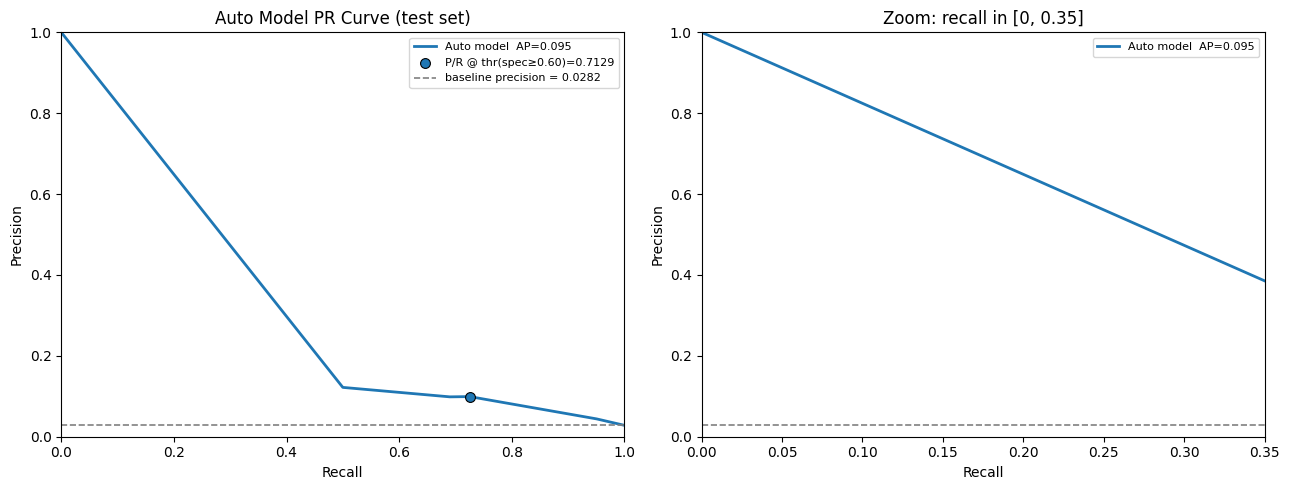

Saved figure: auto_model_pr_curve.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
)

# Ensure auto_model, X_test, y_test, and (critical) the same preprocessing as finetune_oct / evaluate_binary_oct
# Raw X_test would give wrong scores — PR-AUC here must match evaluate_binary_oct (preprocessed matrix).
if "auto_preprocessor" not in globals() or "auto_feature_names" not in globals():
    raise ValueError("Define auto_preprocessor and auto_feature_names (run the IAI autobalance training cell first).")
X_test_for_model = pd.DataFrame(
    auto_preprocessor.transform(X_test),
    columns=auto_feature_names,
)

# Get predicted probabilities for positive class (IAI returns a DataFrame)
_p = (
    auto_model.predict_proba(X_test_for_model)
    if hasattr(auto_model, "predict_proba")
    else auto_model.get_classification_proba(X_test_for_model)
)
if isinstance(_p, pd.DataFrame):
    auto_scores = _p.iloc[:, 1].to_numpy() if _p.shape[1] > 1 else _p.iloc[:, 0].to_numpy()
elif isinstance(_p, pd.Series):
    auto_scores = _p.to_numpy()
else:
    _a = np.asarray(_p)
    auto_scores = _a[:, 1] if _a.ndim == 2 and _a.shape[1] > 1 else _a.ravel()

prevalence = np.mean(y_test)

ap = average_precision_score(y_test, auto_scores)
if "auto_metrics" in globals() and isinstance(auto_metrics, dict):
    ref = auto_metrics.get("pr_auc")
    if isinstance(ref, (int, float)) and np.isfinite(ref):
        print(f"PR-AUC (plot, preprocessed): {ap:.4f}  |  evaluate_binary_oct pr_auc: {ref:.4f}")

precision, recall, _ = precision_recall_curve(y_test, auto_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
color = "tab:blue"

# First panel: full PR curve + marker at threshold from evaluate_binary_oct metrics
axes[0].plot(recall, precision, lw=2, color=color, label=f"Auto model  AP={ap:.3f}")

thr_spec = None
if "auto_metrics" in globals() and isinstance(auto_metrics, dict):
    thr_spec = auto_metrics.get("threshold_specificity_0.6")
if thr_spec is not None and np.isfinite(float(thr_spec)):
    thr_spec = float(thr_spec)
    y_hat = (np.asarray(auto_scores, dtype=float) >= thr_spec).astype(int)
    rp = recall_score(y_test, y_hat, zero_division=0)
    pp = precision_score(y_test, y_hat, zero_division=0)
    axes[0].scatter(
        [rp], [pp], s=50, color=color, edgecolors="k", linewidths=0.8, zorder=5,
        label=f"P/R @ thr(spec≥0.60)={thr_spec:.4f}",
    )

axes[0].axhline(prevalence, color="gray", ls="--", lw=1.2, label=f"baseline precision = {prevalence:.4f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Auto Model PR Curve (test set)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper right", fontsize=8)

# Second panel: zoom on low recall
axes[1].plot(recall, precision, lw=2, color=color, label=f"Auto model  AP={ap:.3f}")
if thr_spec is not None and np.isfinite(float(thr_spec)):
    axes[1].scatter([rp], [pp], s=50, color=color, edgecolors="k", linewidths=0.8, zorder=5)
axes[1].axhline(prevalence, color="gray", ls="--", lw=1.2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Zoom: recall in [0, 0.35]")
axes[1].set_xlim(0, 0.35)
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
out_png = os.path.join(RESULTS_DIR, "auto_model_pr_curve.png") if "RESULTS_DIR" in globals() else "auto_model_pr_curve.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {out_png}")
